## Construct the Circuit using Yao.jl

In [1]:
function twodim_whipcircuit(l::Int64,theta::Float64)
  g_map, _ = whip_2d_sfzy_obc(l)
  nbits = l*l
  circ = chain(nbits, repeat(H, 1:nbits))
  for obj in g_map
    q1, q2, angle = obj
    push!(circ, put((q1,q2)=>zyblock(angle*theta)))
  end
  circ
end

twodim_whipcircuit (generic function with 1 method)

In [ ]:
using Yao, YaoBlocks
using YaoPlots: vizcircuit

In [ ]:
L = 4
n_qubits = L*L
wcirc = twodim_whipcircuit(L, 0.5*pi);

4 4


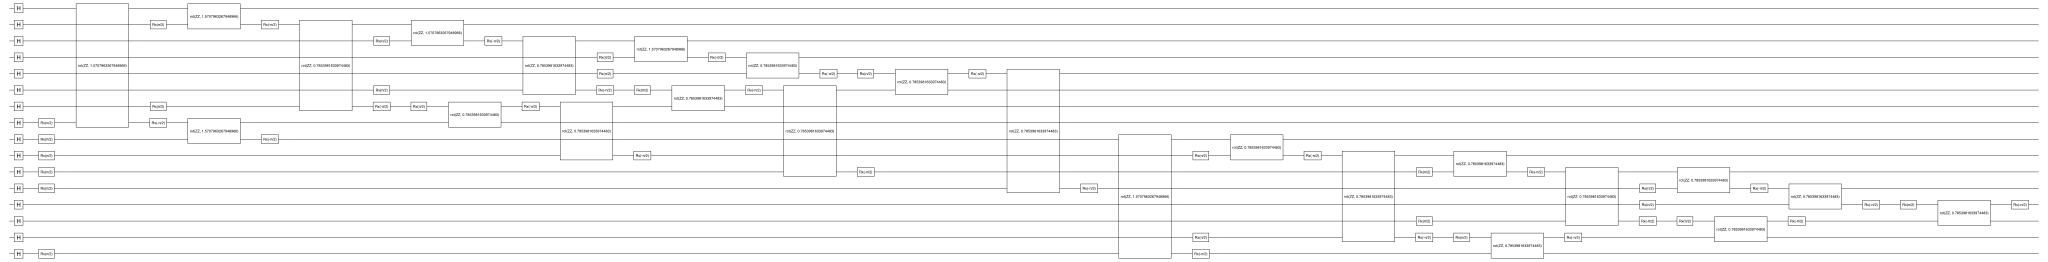

In [ ]:
vizcircuit(wcirc)

In [ ]:
r = zero_state(n_qubits) |> wcirc;
st_r = state(r)[:,1];

In [ ]:
snz = findall(norm.(st_r) .> 1e-9)
[string(idx-1, base=2, pad=n_qubits) for idx in snz]

2-element Vector{String}:
 "0101010101010101"
 "1010101010101010"

In [1]:
using SparseArrays, Statistics, LinearAlgebra

In [2]:
using Makie.Colors
using CairoMakie

In [3]:
include("peps_funcs.jl")

get_maxlinkdim (generic function with 1 method)

In [5]:
L = 8
g_map, c_map = sqr_whip_sfzy_obc(L);

In [6]:
g_map[1:2], c_map[1:2]

(Any[(1, 9, 1.0), (1, 2, 1.0)], Any[((1, 1), (2, 1), 1.0), ((1, 1), (1, 2), 1.0)])

In [7]:
color_dict = Dict("0.5"=>"black", "1.0"=>"red")
xs, ys = Int64[], Int64[]
us, vs = Float64[], Float64[]
ps = []
cs = Int64[]
lcs = String[]
for (i,obj) in enumerate(c_map)
    coor_out, coor_in, angle = obj
    idx_out, idx_in, _ = g_map[i]
    # xs = [coor_out[1], coor_in[1]]
    # ys = [coor_out[2], coor_in[2]]
    push!(xs, coor_out[1])
    push!(ys, coor_out[2])
    push!(us, min(coor_in[1]-coor_out[1], 0.8))
    push!(vs, min(coor_in[2]-coor_out[2], 0.8))
    push!(lcs, color_dict["$(angle)"])
    push!(ps, Point2f(coor_in[1], coor_in[2]))
    push!(cs, idx_in)
end

In [8]:
cgrad(:acton, L^2, categorical = true)

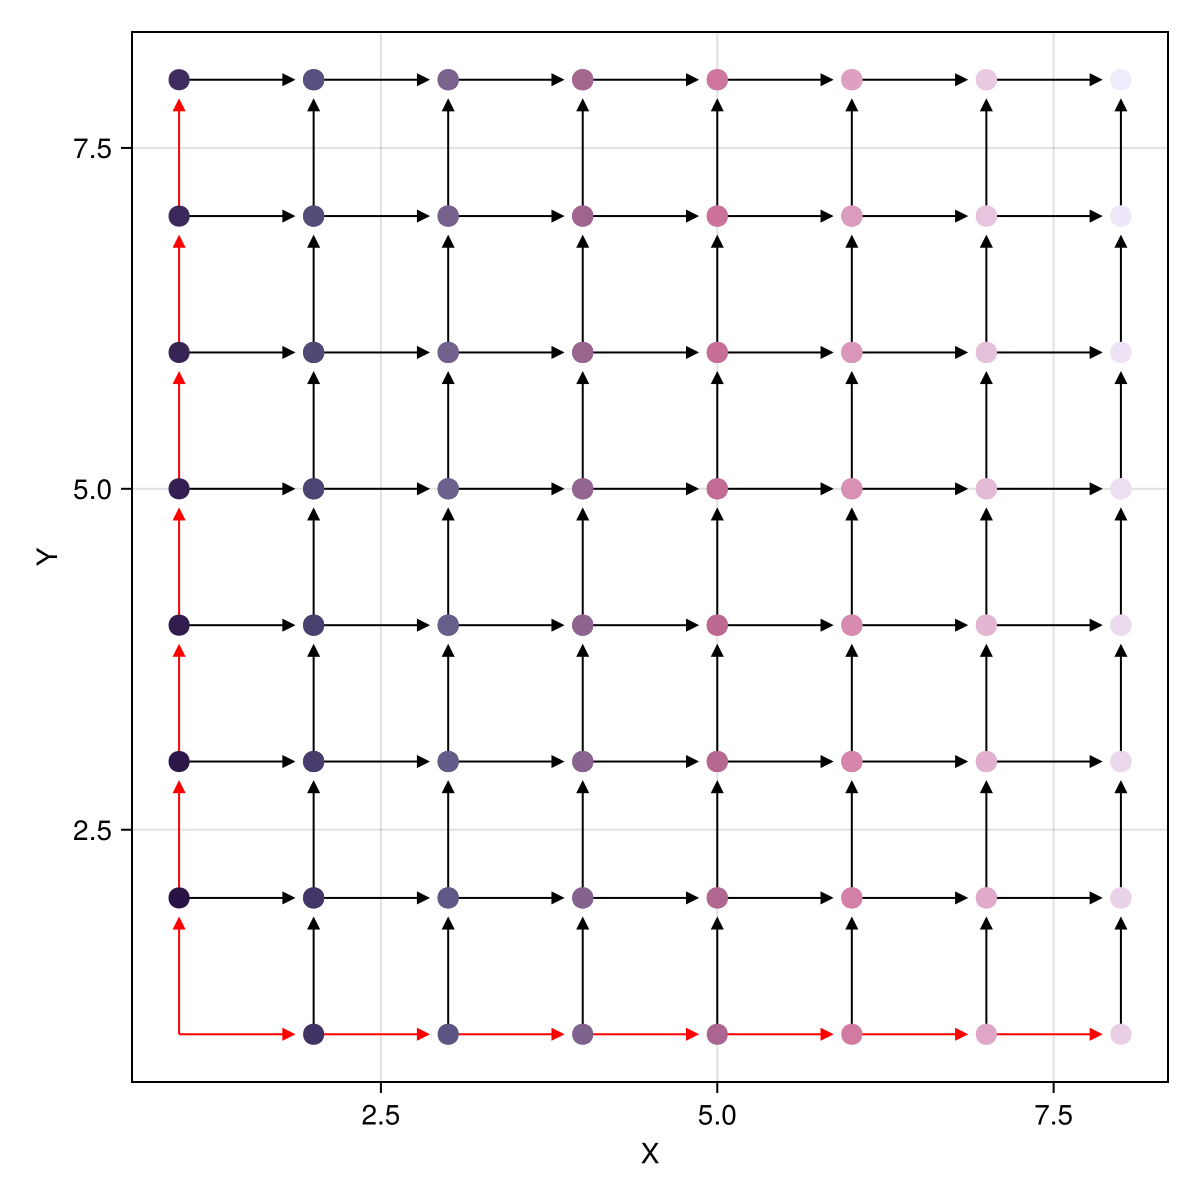

In [9]:
mycls = cgrad(:acton, L^2, categorical = true)
f = Figure(size=(600,600))
ax = Axis(f[1, 1], xlabel="X", ylabel="Y")

arrows!(xs, ys, us, vs, color=lcs, align=:tip)
scatter!(ax, ps, color=mycls[cs], markersize=15)
current_figure()

In [7]:
# @const_gate ZZ::ComplexF64 = [1 0 0 0;0 -1 0 0;0 0 -1 0;0 0 0 1]

In [8]:
# zyblock(a::Float64) = chain(2,
                        # put(2=>rot(X, 0.5*pi)),
                        # put((1,2)=>rot(ZZ, a)),
                        # put(2=>rot(X, -0.5*pi))
                        # )

In [9]:
# mat(zyblock(0.3))

# PEPS

In [1]:
using ITensors, ITensorMPS
include("peps_funcs.jl")

get_maxlinkdim (generic function with 1 method)

## Index exercise

In [43]:
i = Index(2)
j = Index(1)
k = Index(1)
A = random_itensor(i, j, k)
U, S, V = svd(A, [j]);
@show norm(A - U * S * V) <= 10 * eps() * norm(A)

norm(A - U * S * V) <= 10 * eps() * norm(A) = true


true

In [46]:
a = ITensor([1.0,0.0], i, [j, k]...)
array(a)

2×1×1 Array{Float64, 3}:
[:, :, 1] =
 1.0
 0.0

In [20]:
inds_a = (i=>1,j=>2)
A[k=>1,inds_a...]

1.0

In [159]:
for idx in Base.product(1:4,1:2,1:2)
    println(idx)
end

(1, 1, 1)
(2, 1, 1)
(3, 1, 1)
(4, 1, 1)
(1, 2, 1)
(2, 2, 1)
(3, 2, 1)
(4, 2, 1)
(1, 1, 2)
(2, 1, 2)
(3, 1, 2)
(4, 1, 2)
(1, 2, 2)
(2, 2, 2)
(3, 2, 2)
(4, 2, 2)


In [28]:
sites = siteinds("S=1/2", 4)
# 000 state
states = ["Up" for n in 1:4]
ket1 = MPS(sites, states)

MPS
[1] ((dim=2|id=123|"S=1/2,Site,n=1"), (dim=1|id=717|"Link,l=1"))
[2] ((dim=1|id=717|"Link,l=1"), (dim=2|id=325|"S=1/2,Site,n=2"), (dim=1|id=286|"Link,l=2"))
[3] ((dim=1|id=286|"Link,l=2"), (dim=2|id=898|"S=1/2,Site,n=3"), (dim=1|id=592|"Link,l=3"))
[4] ((dim=1|id=592|"Link,l=3"), (dim=2|id=861|"S=1/2,Site,n=4"))


In [38]:
for i in 1:4
    display(array(ket1[i]))
end

2×1 Matrix{Float64}:
 1.0
 0.0

1×2×1 Array{Float64, 3}:
[:, :, 1] =
 1.0  0.0

1×2×1 Array{Float64, 3}:
[:, :, 1] =
 1.0  0.0

1×2 Matrix{Float64}:
 1.0  0.0

# PEPS ansatz

In [2]:
include("peps_funcs.jl")

get_maxlinkdim (generic function with 1 method)

In [3]:
L = 30
ket_es = twodim_sqr_peps(L, "+"^(L*L));
sites = get_siteinds(ket_es)
gates = make_sqr_whip_gates_obc(L, pi/8)
# zytensors = make_tensormap_of_ZY(gates, sites);
zytensors = make_mpomap_of_ZY(gates, sites, "R");

In [4]:
chi = 4
cutoff = 1E-16
psi = deepcopy(ket_es)
# make_contraction_peps!(gates, zytensors, psi, chi, cutoff)
make_mpo_contraction_peps!(gates, zytensors, psi)

In [135]:
# val1 = contract_twopeps_naive(ket_es, ket_es, chi, cutoff, plev=0)
# val2 = contract_twopeps_naive(psi, psi, chi, cutoff, plev=1)
val1, _ = contract_twopeps_bdr_mps(ket_es, ket_es, chi, cutoff, plev=0)
val2, lcoeff2, _ = contract_twopeps_bdr_mps(psi, psi, chi, cutoff, plev=1)
val1, val2, lcoeff2

2 0.9999999999999842 0.002114141292622624
3 0.9999999999999698 0.002114141292622624
4 0.9999999999999547 0.002114141292622624
5 0.9999999999999407 0.002114141292622624
6 0.9999999999999285 0.002114141292622624
7 0.999999999999913 0.002114141292622624
8 0.9999999999998994 0.002114141292622624
9 0.9999999999998861 0.002114141292622624
10 0.9999999999998697 0.002114141292622624
11 0.999999999999855 0.002114141292622624
12 0.9999999999998401 0.002114141292622624
13 0.9999999999998228 0.002114141292622624
14 0.9999999999998106 0.002114141292622624
15 0.9999999999997994 0.002114141292622624
16 0.9999999999997831 0.002114141292622624
17 0.999999999999771 0.002114141292622624
18 0.9999999999997587 0.002114141292622624
19 0.9999999999997432 0.002114141292622624


(0.9999999999999156, 1.3486991523484228e-6, [0.9999999999999843, 0.999999999999968, 0.999999999999955, 0.9999999999999404, 0.999999999999927, 0.9999999999999121, 0.9999999999998984, 0.9999999999998849, 0.9999999999998694, 0.9999999999998552, 0.999999999999839, 0.9999999999998231, 0.9999999999998087, 0.9999999999997977, 0.9999999999997828, 0.9999999999997692, 0.9999999999997571, 0.9999999999997428])

In [12]:
_peps2 = prime.(dag.(psi)) # Index of peps2 is primed
noprime!.(_peps2, tags="Site") # unprime site indices
nbits = length(psi)
l = Int(sqrt(nbits))
pepsc = psi .* _peps2 # because of small linkdim
merge_overlap_links!(pepsc) # merge o==o into o--o
pepsc = reshape(pepsc, (l,l)); # reshape to 2d array
replace_link_with_siteinds!(pepsc)

In [13]:
v1 = MPS(pepsc[:,1])
o1 = MPO(pepsc[:,2])
ov1 = apply(o1, v1; alg="densitymatrix")

MPS
[1] ((dim=2|id=325|"Link,fact"), (dim=4|id=13|"Site,fact"))
[2] ((dim=4|id=933|"Site,fact"), (dim=2|id=187|"Link,fact"), (dim=2|id=325|"Link,fact"))
[3] ((dim=4|id=756|"Site,fact"), (dim=2|id=894|"Link,fact"), (dim=2|id=187|"Link,fact"))
[4] ((dim=4|id=765|"Site,fact"), (dim=2|id=894|"Link,fact"))


In [14]:
(ov1[1]*ov1[1])[1], (ov1[2]*ov1[2])[1], (ov1[3]*ov1[3])[1]

(0.031249999999999965, 2.0000000000000004, 2.0000000000000004)

In [15]:
# check_ground_state_configuration(psi, chi, cutoff)

## Go to larger lattice

In [128]:
L = 10
theta = 0.5*pi
n_sites = L*L
ket_es = twodim_sqr_peps(L, "+"^n_sites);
sites = get_siteinds(ket_es)
gates = make_sqr_whip_gates_obc(L, theta)
# zytensors = make_tensormap_of_ZY(gates, sites);
zytensors = make_mpomap_of_ZY(gates, sites, "R");

In [129]:
chi = 32
cutoff = 1E-16
min_chi = 4
psi = deepcopy(ket_es)
# make_contraction_peps!(gates, zytensors, psi, chi, cutoff)
# println(get_maxlinkdim(psi))
make_mpo_contraction_peps!(gates, zytensors, psi);

In [130]:
# val3, _ = contract_twopeps_naive(psi, psi, chi, cutoff, plev=2)
val3, coeff3, _ = contract_twopeps_bdr_mps(psi, psi, chi, cutoff, plev=1)
val3

0.9999999999999772

## Contraction in the presence of the observable

In [133]:
# apply observable szsz to psi
i0, i1 = 84, 1 #(L-1)*L+1, (L-1)*L+2
szpsi = deepcopy(psi)
szpsi[i0] *= op("X", sites[i0])
noprime!(szpsi[i0], tags="Site")
display(szpsi[i0])
szpsi[i1] *= op("X", sites[i1])
noprime!(szpsi[i1], tags="Site")
display(szpsi[i1])

ITensor ord=5 (dim=2|id=254|"Link,l=140") (dim=2|id=799|"Link,l=158") (dim=2|id=339|"Link,l=159") (dim=2|id=486|"Link,l=160") (dim=2|id=678|"Qubit,Site,n=84")
NDTensors.Dense{Float64, Vector{Float64}}

ITensor ord=3 (dim=2|id=1|"Link,l=1") (dim=2|id=70|"Link,l=2") (dim=2|id=330|"Qubit,Site,n=1")
NDTensors.Dense{Float64, Vector{Float64}}

In [134]:
# szsz_val, _ = contract_twopeps_naive(szpsi, psi, chi, cutoff, plev=2)
szsz_val, coeff_sz, _ = contract_twopeps_bdr_mps(szpsi, psi, chi, cutoff, plev=1)
# szsz_val, coeff_sz, _ = contract_twopeps_bdr_mps(szpsi, ket_es, chi, cutoff, plev=1)
szsz_val / val3, szsz_val

(0.9999999999999992, 0.9999999999999765)

# Show the observable as a function of angle

In [2]:
using CairoMakie
using Makie.Colors
using JLD2
using CSV, DataFrames

In [3]:
include("peps_funcs.jl")

get_maxlinkdim (generic function with 1 method)

In [4]:
ROOT_PATH = "$(homedir())/Documents/QC_whip/code-2d/"
dir_str = "$(ROOT_PATH)/data/"

"/Users/xuhan/Documents/QC_whip/code-2d//data/"

In [4]:
# pauli ORQA
# ref_data = CSV.read("$dir_str/ORQA_L16_ZZ.csv", DataFrame; header=false)
# display(ref_data)
# ref_thetas = ref_data[:,2]
# ref_zzs = ref_data[:,end];

# analytical formula
ref_thetas = Array(-2:0.01:2) .* (pi/4)
ref_zzs = (1 .- abs.(cos.(2ref_thetas)) ) ./ sin.(2ref_thetas);

In [5]:
Ls = [10]
CHIs = [50]
chi = CHIs[1]
Data = Dict{Int64, Any}()
for L in Ls
    file_str = "2D_sqr_PEPS_Whip_MPO_L$(L)_Chi$(chi)_ZZ_Z_Ptrue"
    jldopen("$dir_str/$file_str"*".jld2", "r") do f
        Data[L] = (f["saved_thetas"], f["saved_linkdim"], f["saved_zz"], f["saved_x_x"], f["saved_z"])
    end
end

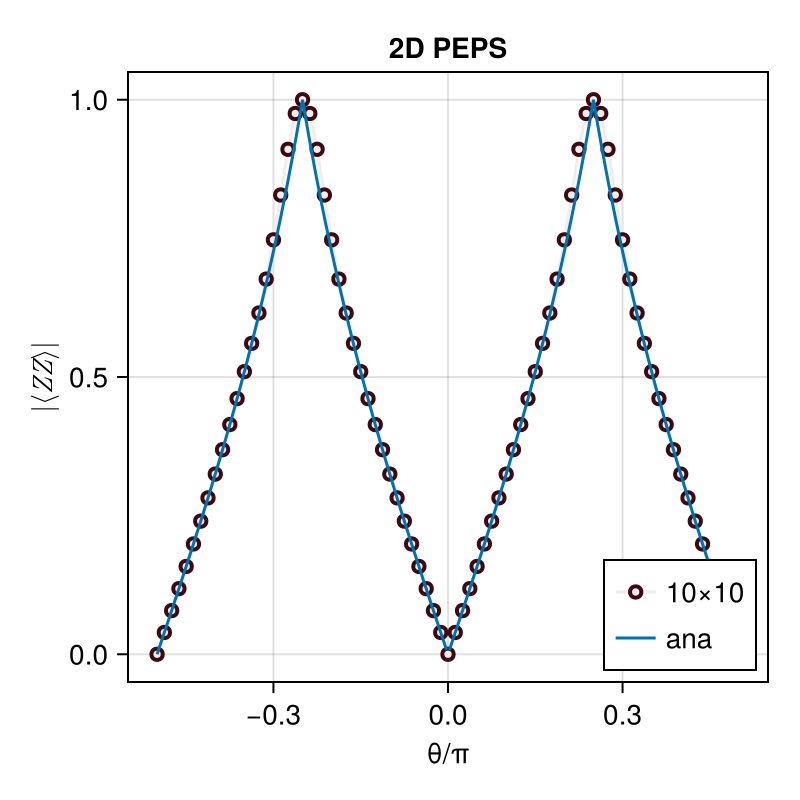

In [6]:
fig = Figure(size = (400, 400))
ax1 = Axis(fig[1, 1], xlabel="θ/π", ylabel=L"|⟨ZZ⟩|", title="2D PEPS")


mycl = cgrad(:amp, length(Ls)+2, categorical = true)
for (i, x) in enumerate(Ls)
    thetas, linkdims, zzs, _, _ = Data[x]
    scatterlines!(ax1, thetas./pi, abs.(zzs)*x^2, color=mycl[i], marker=:circle, strokecolor=mycl[end], markersize=8, strokewidth=2, label = "$(x)×$(x)")
end

lines!(ax1, ref_thetas./pi, abs.(ref_zzs), label="ana")

# Legend(fig[1,2], ax1, position=:rt)
axislegend(ax1, position = :rb)
# save("figure/peps_res_mpo.png", fig)
current_figure()

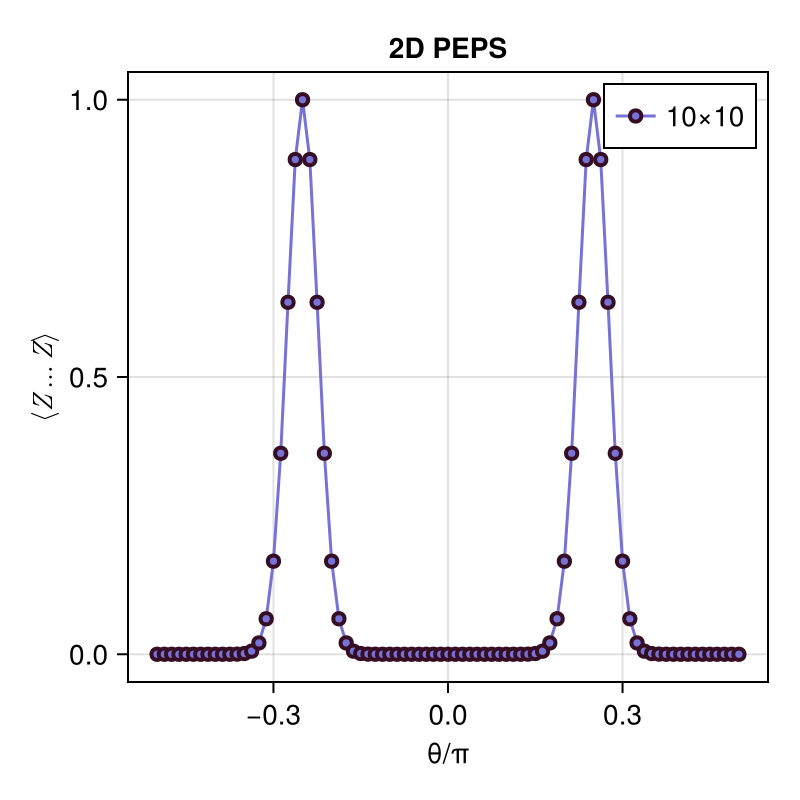

In [7]:
fig = Figure(size = (400, 400))
ax1 = Axis(fig[1, 1], xlabel="θ/π", ylabel=L"⟨Z\dots Z⟩", title="2D PEPS")

mycl = cgrad(:dense, length(Ls)+2, categorical = true)
for (i, x) in enumerate(Ls)
    thetas, linkdims, _, x_x, _ = Data[x]
    scatterlines!(ax1, thetas./pi, x_x, color=mycl[i+1], marker=:circle, strokecolor=mycl[end], markersize=8, strokewidth=2, label = "$(x)×$(x)")
end

# Legend(fig[1,2], ax1, position=:rt)
axislegend(ax1)
# save("figure/peps_res_mpo_xx_boundary.png", fig)
current_figure()

In [9]:
L = Ls[1]

ps = []
for i in 1:L^2
    x,y = idx2coor(i,L)
    push!(ps,Point2f(x,y))
end

In [10]:
thetas,_,_,_,cmat = Data[L];
size(cmat)

(100, 81)

0.05
0.2
0.25
0.3


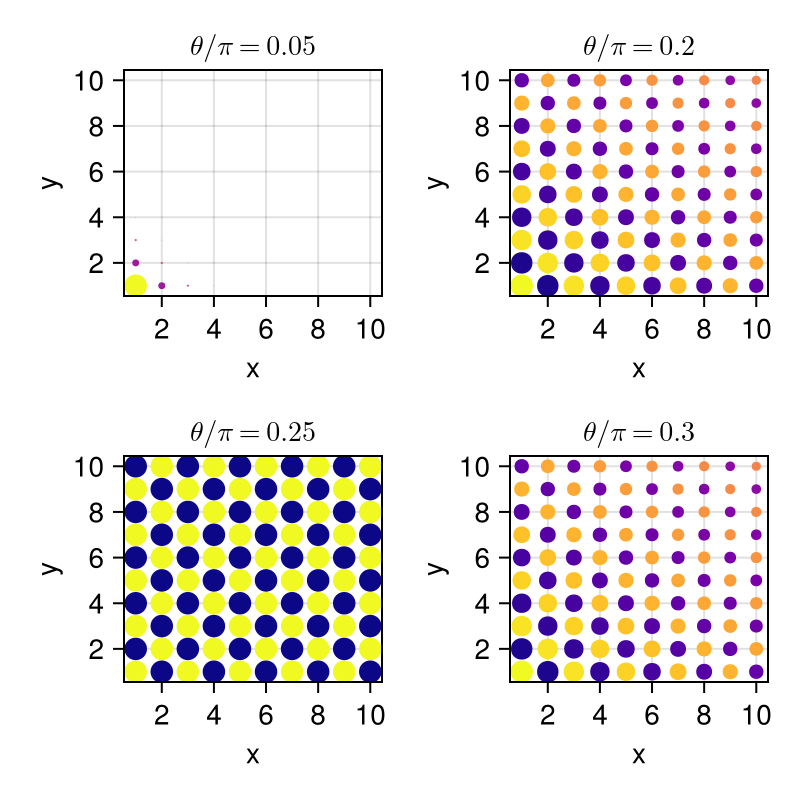

In [11]:
fig = Figure(size = (400, 400))

locs = [(1,1),(1,2),(2,1),(2,2)]
for (i,idx) in enumerate([45,57,61,65])
    println(thetas[idx]/pi)
    vals = cmat[:,idx] .+ 1.0
    vmin, vmax = extrema(vals)
    # norm_vals = (vmax == vmin) ? fill(0.5, length(vals)) : (vals .- vmin) ./ (vmax - vmin)
    r,c = locs[i]
    ax = Axis(fig[r, c], xlabel="x", ylabel="y", title=L"\theta/\pi=%$(thetas[idx]/pi)")
    scatter!(ax, ps, color=vals, markersize=(abs.(vals).-1.0)*16, colorrange=[0,2], colormap=:plasma)
end
# lines(cmat[:,idx])
# lines!(xs)
# lines!(ys)

current_figure()

$\sum_{i}m_i*(-1)^{i_x+i_y}$

In [207]:
#
fm = zeros(length(thetas))
afm = zeros(length(thetas))
for j in eachindex(thetas)
  for i in 1:L^2
    fm[j] += cmat[i,j]
    afm[j] += cmat[i,j]*(-1)^(xs[i]+ys[i])
  end
end
fm ./= L^2;
afm ./= L^2;

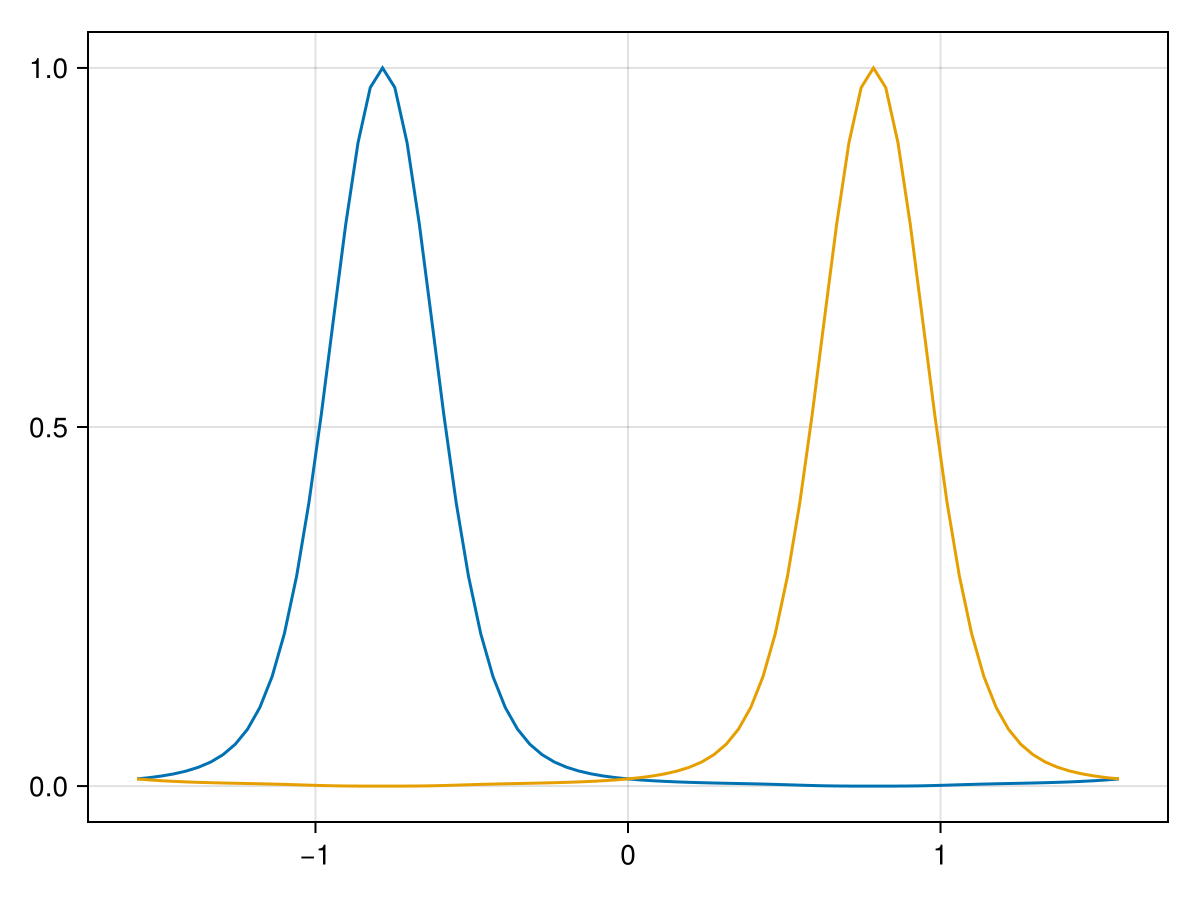

In [208]:
fig = Figure(size = (400, 400))
ax = Axis(fig[1, 1], xlabel="x", ylabel="y")

lines(thetas, fm)
lines!(thetas, afm)

current_figure()

## Scaling

In [5]:
dir_str = "./data/scaling"

"./data/scaling"

In [6]:
L = 100
CHIs = Array(4:2:30)
# println(CHIs)
chi = CHIs[1]
Data = Dict{Int64, Any}()
for chi in CHIs
    file_str = "2D_sqr_PEPS_Whip_MPO_L$(L)_Chi$(chi)_ZZ_scaling"
    jldopen("$dir_str/$file_str"*".jld2", "r") do f
        Data[chi] = (f["saved_thetas"], f["saved_linkdim"], f["saved_zz"], f["total_time_sec"])
    end
end

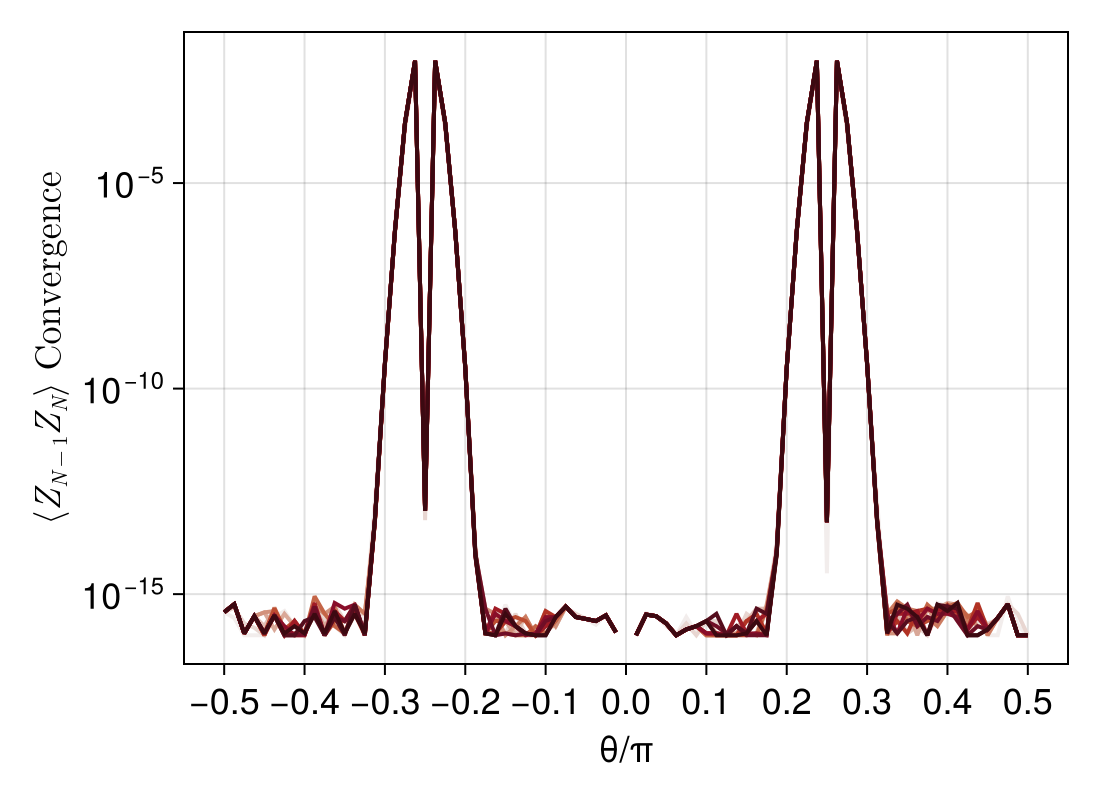

In [8]:
fig = Figure(size = (550, 400), fontsize=18)
ax1 = Axis(fig[1, 1], xlabel="θ/π", ylabel=L"⟨Z_{N-1}Z_{N}⟩~\mathrm{Convergence}", yscale=log10, xticks=-0.5:0.1:0.5)

mycl = cgrad(:amp, length(CHIs), categorical = true)
zzs_ideal = undef
for (i, x) in enumerate(CHIs)
    thetas, linkdims, zzs, total_t = Data[x]
    zzs_ideal = (1 .- abs.(cos.(2thetas)) ) ./ sin.(2thetas);
    dy = max.(abs.(abs.(zzs)*L^2 .- abs.(zzs_ideal)), 1e-16)
    scatterlines!(ax1, thetas./pi, dy, color=mycl[i], label=L"\chi=%$(x)",
            linewidth=2, marker=:circle, markersize=0
    )
end

# Legend(fig[1,2], ax1, position=:rt)
save("figure/peps_res_mpomps_chi_converge_to_ideal.svg", fig)
current_figure()

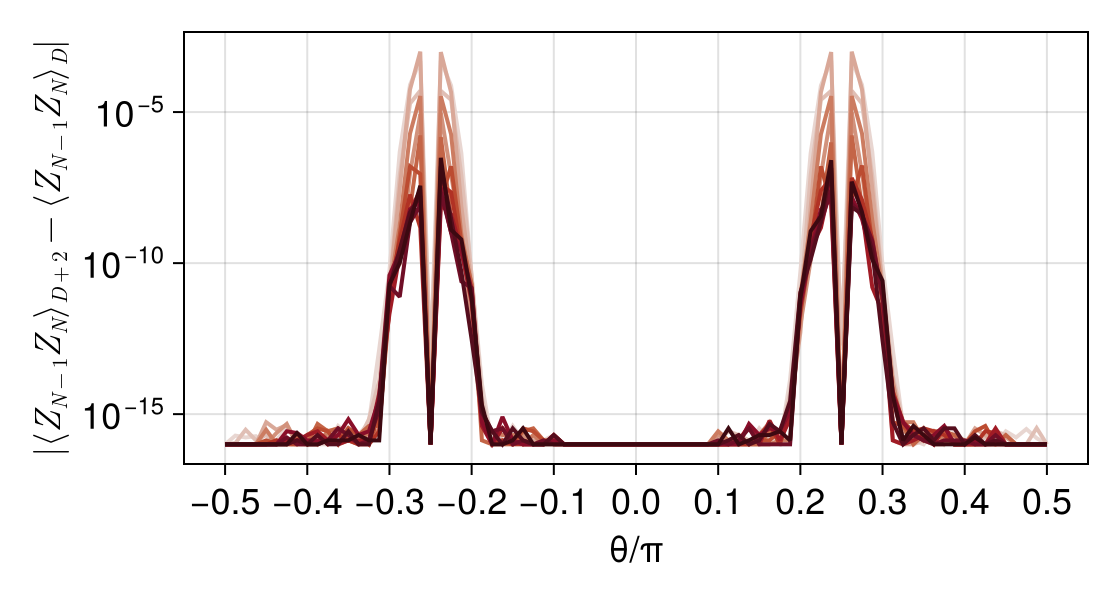

In [7]:
fig = Figure(size = (560, 300), fontsize=18)
ax1 = Axis(fig[1, 1], xlabel="θ/π", ylabel=L"|⟨Z_{N-1}Z_{N}⟩_{D+2}-⟨Z_{N-1}Z_{N}⟩_{D}|", yscale=log10, xticks=-0.5:0.1:0.5)

mycl = cgrad(:amp, length(CHIs), categorical = true)
T_s = []
_, _, zzs_old,_  = Data[CHIs[1]]
for (i, x) in enumerate(CHIs)
    thetas, linkdims, zzs, total_t = Data[x]
    push!(T_s, total_t)
    if i>=2
        dy = max.(abs.(zzs-zzs_old)*L^2, 1e-16)
        scatterlines!(ax1, thetas./pi, dy, color=mycl[i], label=L"D=%$(x)",
            linewidth=2, marker=:circle, markersize=0
            )
    end
    zzs_old = copy(zzs)
end

# Legend(fig[1,2], ax1, position=:rt)
save("figure/peps_res_mpomps_chi_converge.svg", fig)
current_figure()

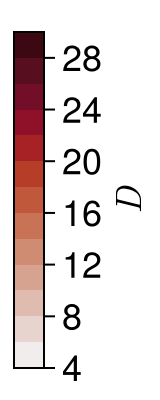

In [11]:
fig_c = Figure(size = (80, 200), fontsize=18)

mycl = cgrad(:amp, length(CHIs), categorical = true)

Colorbar(fig_c[1, 1], limits = (minimum(CHIs), maximum(CHIs)),
    colormap = cgrad(:amp, length(CHIs)-1, categorical = true), 
    size = 15, ticks=4:4:30,
    vertical = true,
    label=L"D"
)
save("figure/peps_res_mpomps_chi_converge_colorbar.svg", fig_c)
fig_c

In [13]:
using Statistics, LsqFit

In [14]:
@. model(x, p) = p[3]+p[1]*x^p[2] #We use `@.` to apply the calculations across all rows.
@. modellog(x, p) = p[1]*log(x) #We use `@.` to apply the calculations across all rows.
@. modellin(x, p) = p[1]*x

modellin (generic function with 1 method)

In [351]:
L = 110
CHIs = Array(4:4:40)
cutoff = 1e-16
T_s_unit = []
for chi in CHIs
    file_str = "2D_sqr_PEPS_Whip_MPO_L$(L)_Chi$(chi)_ZZ_$(chi)_$(cutoff)_time"
    jldopen("$dir_str/$file_str"*".jld2", "r") do f
        total_t = f["total_time_sec"]
        push!(T_s_unit, total_t)
    end
end

In [352]:
p0 = [1.0,2.0,2.0]
fit = curve_fit(model, CHIs, T_s_unit, p0)
dof(fit), coef(fit)

(7, [0.14092995438377443, 1.8305858735294542, 23.262420612823327])

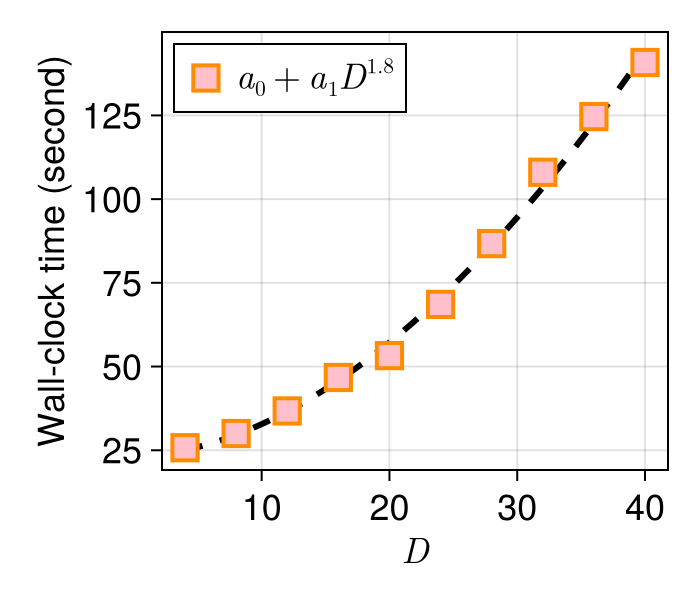

In [353]:
fig2 = Figure(size = (350, 300), fontsize=18)
ax2 = Axis(fig2[1, 1], xlabel=L"D", ylabel="Wall-clock time (second)")

x = Array(4:0.1:40)
lines!(x, model(x, coef(fit)), color=:black, linestyle=:dash, linewidth=3)
scatter!(CHIs, T_s_unit, marker=:rect, markersize=20, color=:pink, 
    strokewidth=2, strokecolor=:darkorange, label=L"a_0+a_1D^{1.8}"
)

axislegend(position=:lt)

save("figure/peps_res_mpomps_chi_scaling.svg", fig2)
fig2

In [354]:
chi = 32
Ls = [30,40,50,60,80,110,150,200]
cutoff=1e-16
T_s_l= []
for L in Ls
    file_str = "2D_sqr_PEPS_Whip_MPO_L$(L)_Chi$(chi)_ZZ_$(chi)_$(cutoff)_time"
    jldopen("$dir_str/$file_str"*".jld2", "r") do f
        total_t = f["total_time_sec"]
        push!(T_s_l, total_t)
    end
end

In [355]:
p0 = [1.0,2.0,2.0]
fit = curve_fit(model, Ls, T_s_l, p0)
dof(fit), coef(fit)

(5, [0.006127645805684766, 2.0470175300843874, 14.374479417174244])

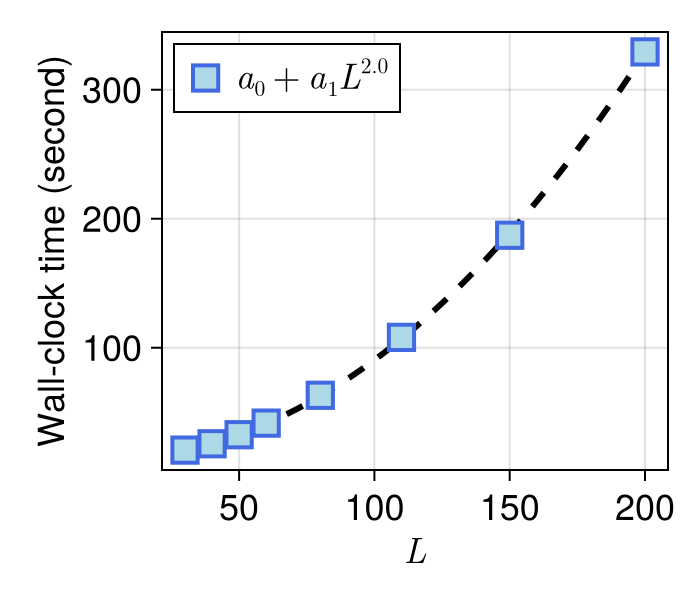

In [357]:
fig3 = Figure(size = (350, 300), fontsize=18)
ax3 = Axis(fig3[1, 1], xlabel=L"L", ylabel="Wall-clock time (second)")

x = Array(30:1:200)
lines!(x, model(x, coef(fit)), color=:black, linestyle=:dash, linewidth=3)
scatter!(Ls, T_s_l, marker=:rect, markersize=20, color=:lightblue, 
    strokewidth=2, strokecolor=:royalblue, label=L"a_0+a_1L^{2.0}"
)

axislegend(position=:lt)

save("figure/peps_res_mpomps_l_scaling.svg", fig3)
fig3

## Bond dimension versus system size at certain cutoff

In [15]:
chi = 1024
# println(CHIs)
Ls = [4 6 8 10 20 30 40 50 60 80 110 150 200][1,:]
cutoffs = [0.0,1e-8,1e-10,1e-12,1e-14,1e-16,1e-18,1e-20]
T_s_dict = Dict()
D_s_dict = Dict()
for cutoff in cutoffs
  T_s_unit = []
  D_s_unit = []
  D_serr_unit = []
  for L in Ls
    if cutoff == 0.0 && L>=8
        continue
    end
    file_str = "2D_sqr_PEPS_Whip_MPO_L$(L)_Chi$(chi)_ZZ_$(chi)_$(cutoff)"
    jldopen("$dir_str/$file_str"*".jld2", "r") do f
        total_t = f["total_time_sec"]
        push!(T_s_unit, total_t)
        LinkD = f["saved_linkdim"]
        # print(stack(LinkD)[end,:])
        Dm = maximum(stack(LinkD)[end,:])
        Derr = std(stack(LinkD)[end,:])
        push!(D_s_unit, Dm)
        push!(D_serr_unit, Derr)
    end
  end
  T_s_dict[cutoff] = T_s_unit
  D_s_dict[cutoff] = (D_s_unit, D_serr_unit)
end

In [16]:
D_s_dict

Dict{Any, Any} with 8 entries:
  0.0     => (Any[64, 1024], Any[0.707107, 3.53553])
  1.0e-12 => (Any[4, 8, 10, 10, 13, 14, 14, 14, 14, 14, 14, 14, 14], Any[0.0, 1…
  1.0e-14 => (Any[4, 8, 10, 12, 14, 16, 17, 17, 17, 17, 17, 17, 17], Any[0.0, 0…
  1.0e-20 => (Any[37, 44, 50, 56, 74, 81, 89, 91, 94, 93, 95, 98, 98], Any[1.41…
  1.0e-18 => (Any[35, 33, 38, 47, 58, 60, 62, 61, 63, 63, 64, 65, 66], Any[0.0,…
  1.0e-8  => (Any[4, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6], Any[0.0, 0.707107, 1.…
  1.0e-10 => (Any[4, 6, 6, 8, 10, 10, 10, 10, 10, 10, 10, 10, 10], Any[0.0, 0.0…
  1.0e-16 => (Any[4, 8, 19, 25, 38, 37, 39, 36, 36, 35, 34, 37, 37], Any[0.0, 0…

6[2.071436069344684]
6[3.027100076333142]
6[4.128214920014644]
6[4.648981163098283]
6[10.233413746309363]
6[18.430785566745612]
6[24.301230691267726]


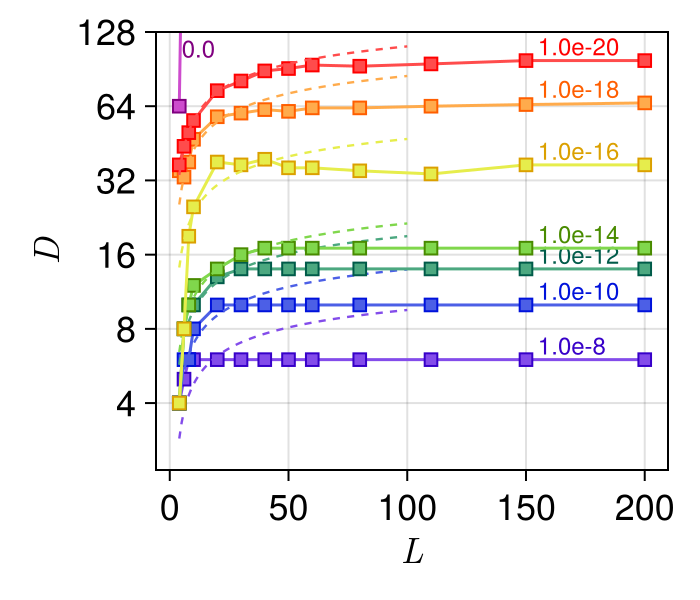

In [26]:
fig4 = Figure(size = (350, 300), fontsize=18)
ax4 = Axis(fig4[1, 1], xlabel=L"L", ylabel=L"D", yscale=log2, yticks=2 .^[2,3,4,5,6,7])

mycl = cgrad(:lightrainbow, length(cutoffs), categorical = true)
mycle = cgrad(:rainbow, length(cutoffs), categorical = true)
for (i,cutoff) in enumerate(cutoffs)
    ydata, yerr = D_s_dict[cutoff]
    scatterlines!(Ls[1:length(ydata)], ydata, marker=:rect, markersize=10, color=mycl[i], 
        strokewidth=1, strokecolor=mycle[i], label="$(cutoff)", linestyle=:solid
    )
    if i==1
        text!((Ls[1]+Ls[2])/2, ydata[1]*1.5; text="$(cutoff)", fontsize=12, color=mycle[i])
    else
        p0 = [0.1]
        xfit, yfit = Ls[Ls.<50 .&& Ls.>1], ydata[Ls.<50 .&& Ls.>1]
        fit = curve_fit(modellog, xfit, yfit, p0)
        println(dof(fit), coef(fit))
        text!((Ls[end-2]+Ls[end])/2, ydata[end]; text="$(cutoff)", fontsize=12, color=mycle[i])
        xpath = Array(Ls[1]:1:100)
        lines!(xpath, modellog(xpath, coef(fit)), color=mycl[i], linewidth=1.2, linestyle=:dash)
    end
end

ylims!(ax4, nothing, 2^7)

save("figure/peps_res_mpomps_D_vs_L.svg", fig4)

fig4

In [298]:
mycl = cgrad(:lightrainbow, length(cutoffs), categorical = true)
mycle = cgrad(:rainbow, length(cutoffs), categorical = true)
D_vs_cutoff = Int[]
for (i,cutoff) in enumerate(cutoffs)
    if i==1
        continue
    end
    ydata, yerr = D_s_dict[cutoff]
    push!(D_vs_cutoff, ydata[end])
end

In [361]:
p0 = [0.1]
xfit = cutoffs[2:end]
yfit = D_vs_cutoff
fit = curve_fit(modellin, log.(xfit), log.(yfit), p0)
println(dof(fit), coef(fit))

6[-0.09762302645363348]


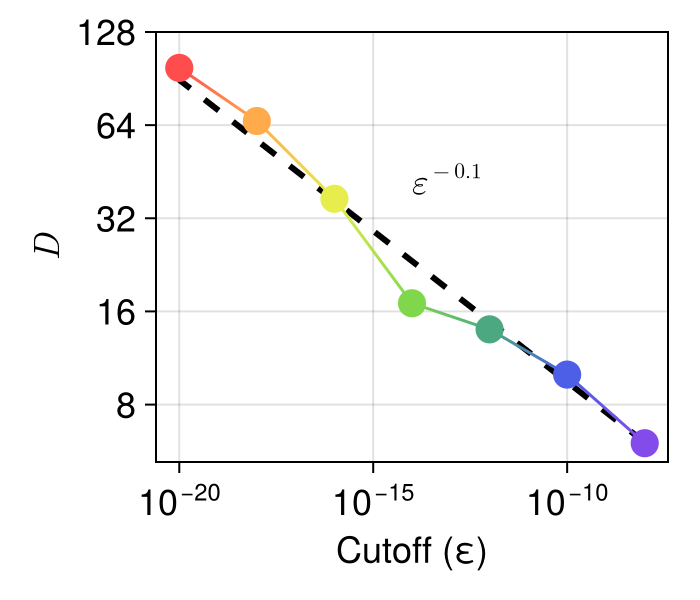

In [380]:
fig4 = Figure(size = (350, 300), fontsize=18)
ax4 = Axis(fig4[1, 1], xlabel="Cutoff (ε)", ylabel=L"D", xscale=log10, yscale=log2, yticks=2 .^[2,3,4,5,6,7])

mycl = cgrad(:lightrainbow, length(cutoffs), categorical = true)
mycle = cgrad(:rainbow, length(cutoffs), categorical = true)

lines!(xfit, exp.(modellin(log.(xfit), coef(fit))), color=:black, linestyle=:dash, linewidth=3)
scatterlines!(cutoffs[2:end], D_vs_cutoff, color=mycl[2:end], markersize=20)
text!(cutoffs[5], exp.(modellin(log.(xfit)[5], coef(fit))); text=L"\varepsilon^{-0.1}")

ylims!(ax4, nothing, 2^7)

save("figure/peps_res_mpomps_D_vs_cutoff.svg", fig4)

fig4